# scaling_train_size — analysis

Loads `results/summary.parquet` produced by `run.py` and plots how
loss, held-out energy error, and wall time scale with the number of
training orbits.

Re-run `python run.py` whenever the sweep grid changes; this notebook
should never train.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 18 
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.top'] = True
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'STIXGeneral'
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True


df = pd.read_parquet(Path('results') / 'summary.parquet')
df.head()

,data.omega,data.n_orbits,data.n_steps,data.r_bounds,potential.name,model.class,model.input_dim,model.n_layers,model.layer_class,model.conditioner.class,...,git_sha,git_dirty,hostname,platform,python_version,torch_version,run_id,peak_gpu_mb,gpu_name,cuda_version
0,1.5,16,64,"[0.15, 0.75]",MWPotential2014_1D,HamiltonianMappingModel,2,10,SymplecticCouplingLayer,SimpleNNConditioner,...,e44540b,True,geir,Linux-6.8.0-110-generic-x86_64-with-glibc2.39,3.12.8,2.11.0+cu130,6a4fd81c84,NaN,None,None
1,1.5,16,128,"[0.15, 0.75]",MWPotential2014_1D,HamiltonianMappingModel,2,10,SymplecticCouplingLayer,SimpleNNConditioner,...,e44540b,True,geir,Linux-6.8.0-110-generic-x86_64-with-glibc2.39,3.12.8,2.11.0+cu130,ab9cb501ad,NaN,None,None
2,1.5,16,256,"[0.15, 0.75]",MWPotential2014_1D,HamiltonianMappingModel,2,10,SymplecticCouplingLayer,SimpleNNConditioner,...,e44540b,True,geir,Linux-6.8.0-110-generic-x86_64-with-glibc2.39,3.12.8,2.11.0+cu130,a0640e6eb6,NaN,None,None
3,1.5,16,512,"[0.15, 0.75]",MWPotential2014_1D,HamiltonianMappingModel,2,10,SymplecticCouplingLayer,SimpleNNConditioner,...,e44540b,True,geir,Linux-6.8.0-110-generic-x86_64-with-glibc2.39,3.12.8,2.11.0+cu130,0000680b41,NaN,None,None
4,1.5,16,1028,"[0.15, 0.75]",MWPotential2014_1D,HamiltonianMappingModel,2,10,SymplecticCouplingLayer,SimpleNNConditioner,...,e44540b,True,geir,Linux-6.8.0-110-generic-x86_64-with-glibc2.39,3.12.8,2.11.0+cu130,0cfae99dcb,NaN,None,None


In [2]:
# df = df[df['training.steps'] == 200]
df

,data.omega,data.n_orbits,data.n_steps,data.r_bounds,potential.name,model.class,model.input_dim,model.n_layers,model.layer_class,model.conditioner.class,...,git_sha,git_dirty,hostname,platform,python_version,torch_version,run_id,peak_gpu_mb,gpu_name,cuda_version
0,1.5,16,64,"[0.15, 0.75]",MWPotential2014_1D,HamiltonianMappingModel,2,10,SymplecticCouplingLayer,SimpleNNConditioner,...,e44540b,True,geir,Linux-6.8.0-110-generic-x86_64-with-glibc2.39,3.12.8,2.11.0+cu130,6a4fd81c84,NaN,None,None
1,1.5,16,128,"[0.15, 0.75]",MWPotential2014_1D,HamiltonianMappingModel,2,10,SymplecticCouplingLayer,SimpleNNConditioner,...,e44540b,True,geir,Linux-6.8.0-110-generic-x86_64-with-glibc2.39,3.12.8,2.11.0+cu130,ab9cb501ad,NaN,None,None
2,1.5,16,256,"[0.15, 0.75]",MWPotential2014_1D,HamiltonianMappingModel,2,10,SymplecticCouplingLayer,SimpleNNConditioner,...,e44540b,True,geir,Linux-6.8.0-110-generic-x86_64-with-glibc2.39,3.12.8,2.11.0+cu130,a0640e6eb6,NaN,None,None
3,1.5,16,512,"[0.15, 0.75]",MWPotential2014_1D,HamiltonianMappingModel,2,10,SymplecticCouplingLayer,SimpleNNConditioner,...,e44540b,True,geir,Linux-6.8.0-110-generic-x86_64-with-glibc2.39,3.12.8,2.11.0+cu130,0000680b41,NaN,None,None
4,1.5,16,1028,"[0.15, 0.75]",MWPotential2014_1D,HamiltonianMappingModel,2,10,SymplecticCouplingLayer,SimpleNNConditioner,...,e44540b,True,geir,Linux-6.8.0-110-generic-x86_64-with-glibc2.39,3.12.8,2.11.0+cu130,0cfae99dcb,NaN,None,None
5,1.5,32,64,"[0.15, 0.75]",MWPotential2014_1D,HamiltonianMappingModel,2,10,SymplecticCouplingLayer,SimpleNNConditioner,...,e44540b,True,geir,Linux-6.8.0-110-generic-x86_64-with-glibc2.39,3.12.8,2.11.0+cu130,eaa2ddaebd,NaN,None,None
6,1.5,32,128,"[0.15, 0.75]",MWPotential2014_1D,HamiltonianMappingModel,2,10,SymplecticCouplingLayer,SimpleNNConditioner,...,e44540b,True,geir,Linux-6.8.0-110-generic-x86_64-with-glibc2.39,3.12.8,2.11.0+cu130,98faad9984,NaN,None,None
7,1.5,32,256,"[0.15, 0.75]",MWPotential2014_1D,HamiltonianMappingModel,2,10,SymplecticCouplingLayer,SimpleNNConditioner,...,e44540b,True,geir,Linux-6.8.0-110-generic-x86_64-with-glibc2.39,3.12.8,2.11.0+cu130,696a2f15be,NaN,None,None
8,1.5,32,512,"[0.15, 0.75]",MWPotential2014_1D,HamiltonianMappingModel,2,10,SymplecticCouplingLayer,SimpleNNConditioner,...,e44540b,True,geir,Linux-6.8.0-110-generic-x86_64-with-glibc2.39,3.12.8,2.11.0+cu130,c5f1b355bd,NaN,None,None
9,1.5,32,1028,"[0.15, 0.75]",MWPotential2014_1D,HamiltonianMappingModel,2,10,SymplecticCouplingLayer,SimpleNNConditioner,...,e44540b,True,geir,Linux-6.8.0-110-generic-x86_64-with-glibc2.39,3.12.8,2.11.0+cu130,2afc4bd668,NaN,None,None


In [3]:
# norbits = 'data.n_orbits'
# agg_norbits = df.groupby(norbits).agg(
#     final_loss_mean=('final_loss', 'mean'),
#     final_loss_std=('final_loss', 'std'),
#     eval_mean_error_max=('eval_mean_error_max', 'mean'),
#     eval_mean_error_max_std=('eval_mean_error_max', 'std'),
#     eval_max_error_mean=('eval_max_error_mean', 'mean'),
#     eval_max_error_max=('eval_max_error_max', 'max'),
#     wall_time_mean=('wall_time_s', 'mean'),
#     wall_time_std=('wall_time_s', 'std'),
# ).reset_index()
# agg_norbits

In [4]:
df['data.n_pts'] = df['data.n_orbits'] * df['data.n_steps']

# Training Evaluation

How well did the models train?

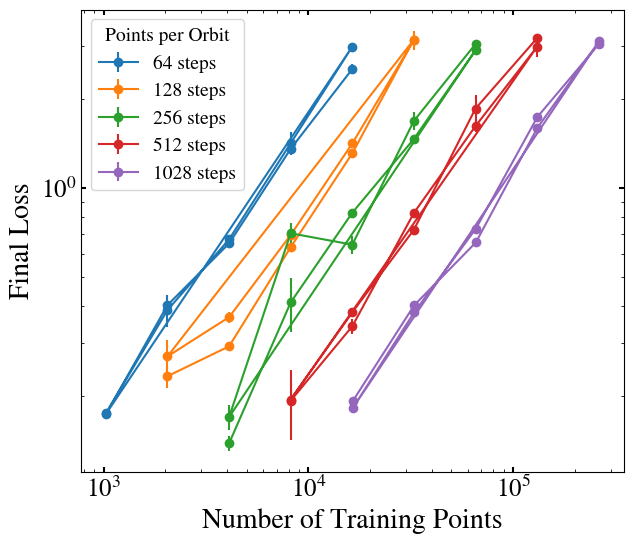

In [5]:
# plot eval_mean_error_mean as a function of n_orbits, with a separate line for each n_steps
plt.figure(figsize=(7, 6))
for n_steps in df['data.n_steps'].unique():
    subset = df[df['data.n_steps'] == n_steps]
    plt.errorbar(subset['data.n_pts'], subset['tail_mean_loss'], yerr=subset['tail_std_loss'], marker='o', label=f'{n_steps} steps')
plt.xlabel('Number of Training Points', fontsize=20)
plt.ylabel('Final Loss', fontsize=20)
plt.yscale('log')
plt.xscale('log')
plt.legend(title='Points per Orbit')

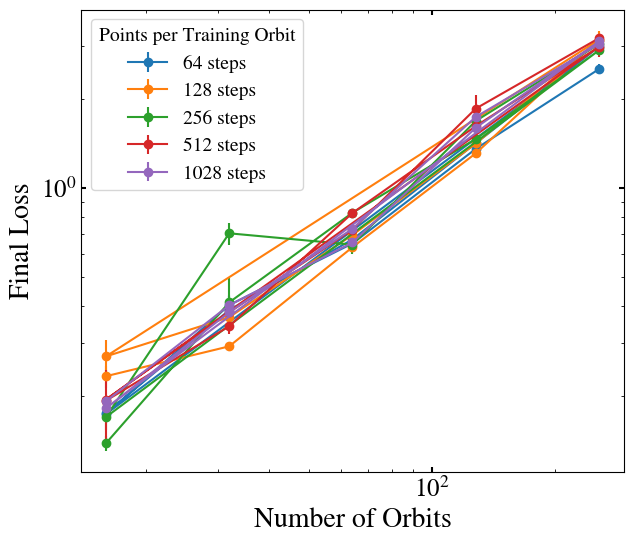

In [6]:
# plot eval_mean_error_mean as a function of n_orbits, with a separate line for each n_steps
plt.figure(figsize=(7, 6))
for n_steps in df['data.n_steps'].unique():
    subset = df[df['data.n_steps'] == n_steps]
    plt.errorbar(subset['data.n_orbits'], subset['tail_mean_loss'], yerr=subset['tail_std_loss'], marker='o', label=f'{n_steps} steps')
plt.xlabel('Number of Orbits', fontsize=20)
plt.ylabel('Final Loss', fontsize=20)
plt.yscale('log')
plt.xscale('log')
plt.legend(title='Points per Training Orbit')

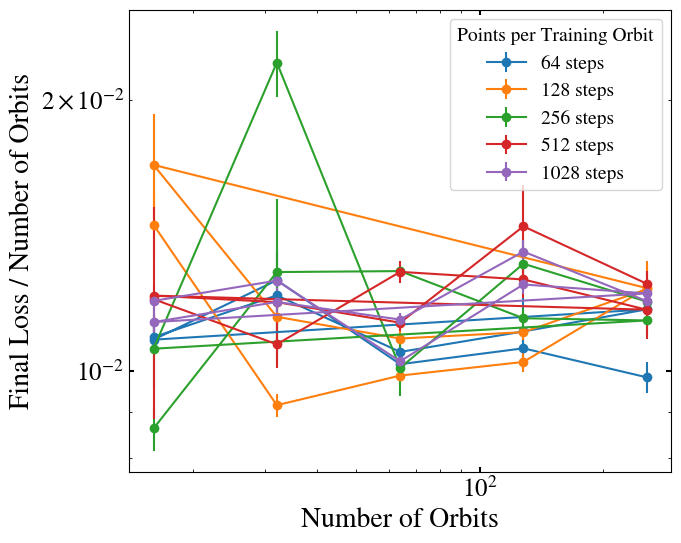

In [7]:
# plot eval_mean_error_mean as a function of n_orbits, with a separate line for each n_steps
plt.figure(figsize=(7, 6))
for n_steps in df['data.n_steps'].unique():
    subset = df[df['data.n_steps'] == n_steps]
    plt.errorbar(subset['data.n_orbits'], subset['tail_mean_loss']/subset['data.n_orbits'], yerr=subset['tail_std_loss']/subset['data.n_orbits'], marker='o', label=f'{n_steps} steps')
plt.xlabel('Number of Orbits', fontsize=20)
plt.ylabel('Final Loss / Number of Orbits', fontsize=20)
plt.yscale('log')
plt.xscale('log')
plt.legend(title='Points per Training Orbit')

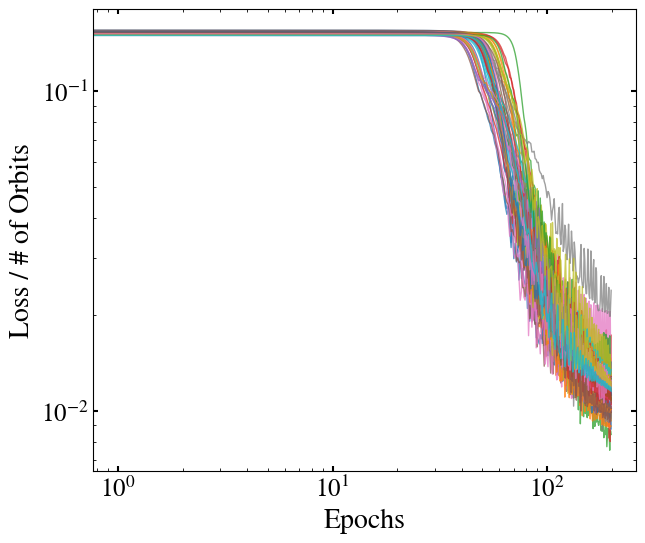

In [8]:
# from mat
plt.figure(figsize=(7, 6))

for n_orbits in df['data.n_orbits'].unique():
    subset = df[df['data.n_orbits'] == n_orbits]
    for subset_id in subset['run_id']:
        filepath = Path('results') / 'runs'
        loss = np.load(filepath / subset_id / 'loss_curve.npy')
        plt.loglog(loss / n_orbits, lw=1, alpha=0.75)
    #plt.errorbar(subset['data.n_orbits'], subset['tail_mean_loss'], yerr=subset['tail_std_loss'], marker='o', label=f'{n_steps} steps')
plt.xlabel('Epochs', fontsize=20)
plt.ylabel('Loss / # of Orbits', fontsize=20)
plt.yscale('log')
plt.xscale('log')

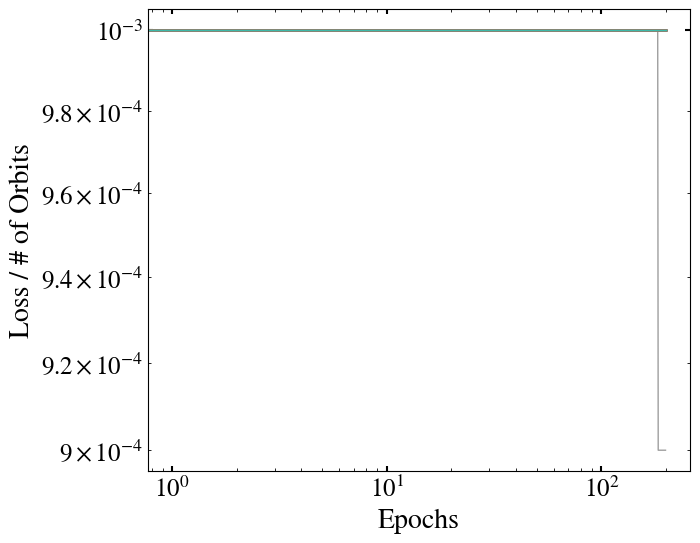

In [12]:
plt.figure(figsize=(7, 6))

for n_orbits in df['data.n_orbits'].unique():
    subset = df[df['data.n_orbits'] == n_orbits]
    for subset_id in subset['run_id']:
        filepath = Path('results') / 'runs'
        lr = np.load(filepath / subset_id / 'lr_curve.npy')
        plt.loglog(lr, lw=1, alpha=0.75)
    #plt.errorbar(subset['data.n_orbits'], subset['tail_mean_loss'], yerr=subset['tail_std_loss'], marker='o', label=f'{n_steps} steps')
plt.xlabel('Epochs', fontsize=20)
plt.ylabel('Loss / # of Orbits', fontsize=20)
plt.yscale('log')
plt.xscale('log')

In [13]:
# filepath = Path('results') / 'runs'
# plt.figure(figsize=(8,6))
# for rundir in filepath.iterdir():
#     loss = np.load(rundir/'loss_curve.npy')
#     plt.loglog(loss)
# plt.xlabel('Epochs')
# plt.ylabel('Loss')

# Performance Analysis

In [14]:
import numpy as np
import matplotlib.pyplot as plt

df_pivot = df.pivot(
    index='data.n_orbits',
    columns='data.n_steps',
    values='eval_max_error_mean'
)

x = df_pivot.columns.to_numpy()   # n_steps
y = df_pivot.index.to_numpy()     # n_orbits
z = np.log10(df_pivot.to_numpy())


x_plot = np.log2(x)
y_plot = np.log2(y)

fig, ax = plt.subplots(figsize=(7,7))

pcm = ax.pcolormesh(x_plot, y_plot, z, shading='auto', cmap='plasma')

ax.set_xticks(x_plot)
ax.set_xticklabels(x)

ax.set_yticks(y_plot)
ax.set_yticklabels(y)

ax.set_aspect('equal')

# Add text inside each cell
for i in range(len(y)):
    for j in range(len(x)):
        ax.text(
            x_plot[j],
            y_plot[i],
            f"{z[i, j]:.2f}",   # format to 2 decimals
            ha='center',
            va='center',
            fontsize=15
        )

fig.colorbar(pcm, label="")

plt.xlabel("Points per Orbit", fontsize=20)
plt.ylabel("Number of Orbits", fontsize=20)

plt.show()


ValueError: Index contains duplicate entries, cannot reshape

### Worst Error of all points

$i$ = index of point along an orbit

$j$ = index of orbit

<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1658111/2245333108.py:7: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('$\max_j \left ( \max_i \left (\\frac{H}{\\langle H \\rangle_i} \\right ) \\right )$', fontsize=25)


Text(0.5, 1.0, 'Worst Error of All Points')

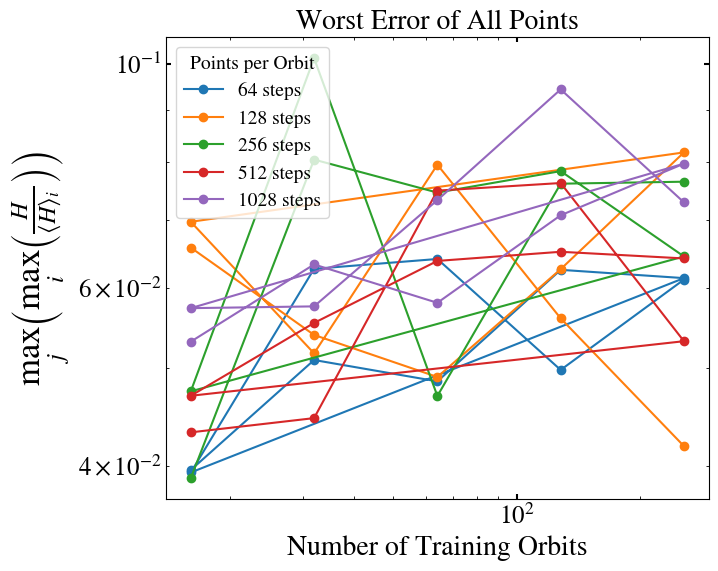

In [15]:
# plot eval_mean_error_mean as a function of n_orbits, with a separate line for each n_steps
plt.figure(figsize=(7, 6))
for n_steps in df['data.n_steps'].unique():
    subset = df[df['data.n_steps'] == n_steps]
    plt.loglog(subset['data.n_orbits'], subset['eval_max_error_max'], marker='o', label=f'{n_steps} steps')
plt.xlabel('Number of Training Orbits', fontsize=20)
plt.ylabel('$\max_j \left ( \max_i \left (\\frac{H}{\\langle H \\rangle_i} \\right ) \\right )$', fontsize=25)
plt.legend(title='Points per Orbit')
plt.title('Worst Error of All Points', fontsize=20)

### Mean of the average error along orbits

<>:7: SyntaxWarning: invalid escape sequence '\l'
<>:7: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1658111/646370077.py:7: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\left \\langle \left \\langle \\frac{H}{\\langle H \\rangle_{i}} \\right \\rangle_{i} \\right \\rangle_{j}$', fontsize=25)


Text(0.5, 1.0, 'Mean of the Average Error Along Orbits')

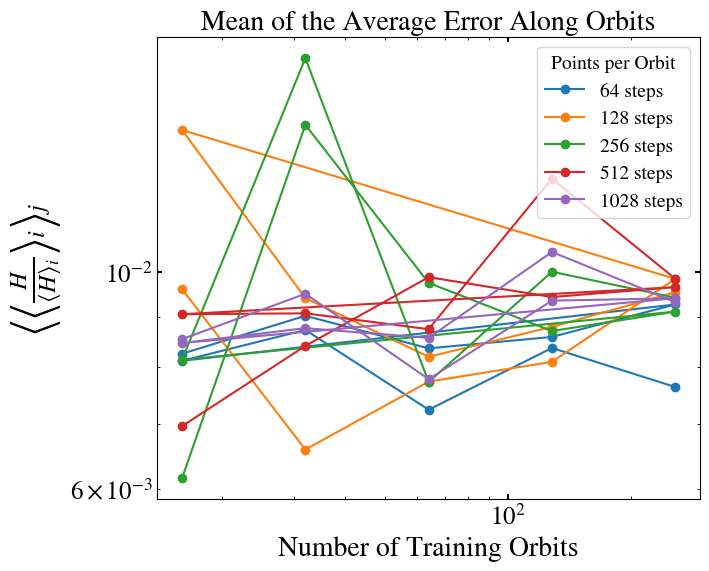

In [16]:
# plot eval_mean_error_mean as a function of n_orbits, with a separate line for each n_steps
plt.figure(figsize=(7, 6))
for n_steps in df['data.n_steps'].unique():
    subset = df[df['data.n_steps'] == n_steps]
    plt.loglog(subset['data.n_orbits'], subset['eval_mean_error_mean'], marker='o', label=f'{n_steps} steps')
plt.xlabel('Number of Training Orbits', fontsize=20)
plt.ylabel('$\left \\langle \left \\langle \\frac{H}{\\langle H \\rangle_{i}} \\right \\rangle_{i} \\right \\rangle_{j}$', fontsize=25)
plt.legend(title='Points per Orbit')
plt.title('Mean of the Average Error Along Orbits', fontsize=20)

## Mean of the worst errors along orbits

<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1658111/3134691030.py:6: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\left \\langle \max_i \left ( \\frac{H}{\\langle H \\rangle_{i}} \\right ) \\right \\rangle_{j}$', fontsize=25)


Text(0.5, 1.0, 'Mean of the Worst Errors along Orbits')

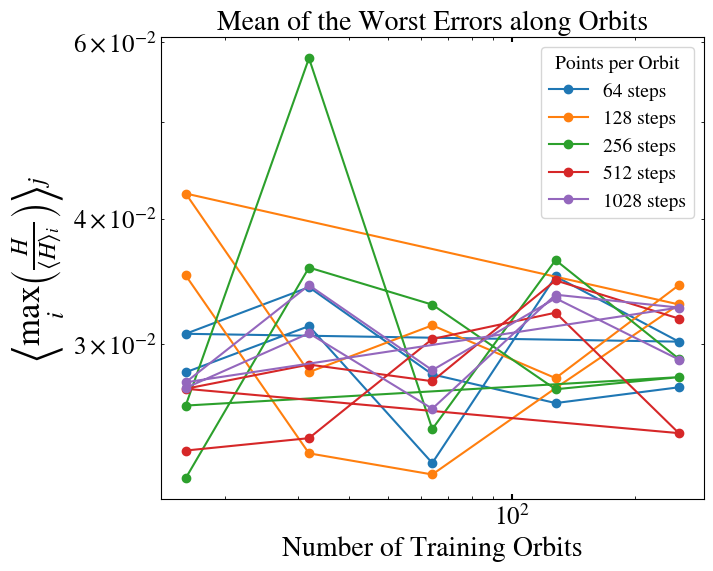

In [17]:
plt.figure(figsize=(7, 6))
for n_steps in df['data.n_steps'].unique():
    subset = df[df['data.n_steps'] == n_steps]
    plt.loglog(subset['data.n_orbits'], subset['eval_max_error_mean'], marker='o', label=f'{n_steps} steps')
plt.xlabel('Number of Training Orbits', fontsize=20)
plt.ylabel('$\left \\langle \max_i \left ( \\frac{H}{\\langle H \\rangle_{i}} \\right ) \\right \\rangle_{j}$', fontsize=25)
plt.legend(title='Points per Orbit')
plt.title('Mean of the Worst Errors along Orbits', fontsize=20)

## Worst of the mean errors along orbits

<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1658111/2739118183.py:6: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('$ \max_j \left ( \left \\langle \\frac{H}{\\langle H \\rangle_{i}} \\right \\rangle_{i} \\right )$', fontsize=25)


Text(0.5, 1.0, 'Worst of the Mean Errors Along Orbits')

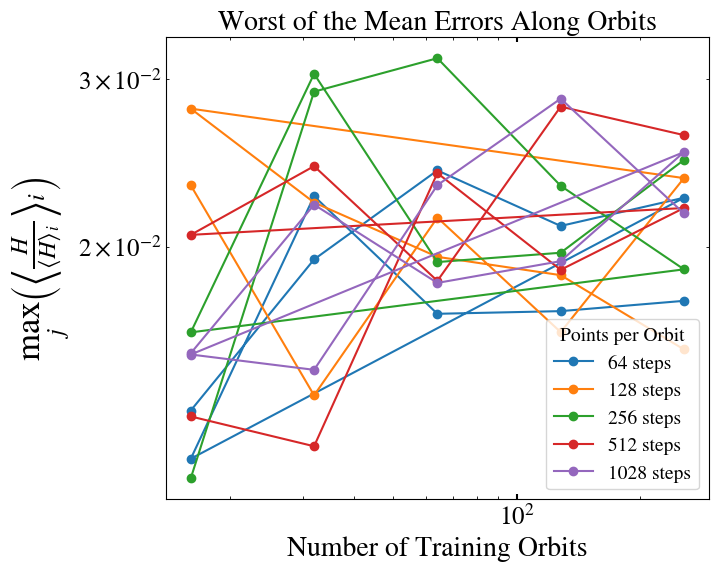

In [18]:
plt.figure(figsize=(7, 6))
for n_steps in df['data.n_steps'].unique():
    subset = df[df['data.n_steps'] == n_steps]
    plt.loglog(subset['data.n_orbits'], subset['eval_mean_error_max'], marker='o', label=f'{n_steps} steps')
plt.xlabel('Number of Training Orbits', fontsize=20)
plt.ylabel('$ \max_j \left ( \left \\langle \\frac{H}{\\langle H \\rangle_{i}} \\right \\rangle_{i} \\right )$', fontsize=25)
plt.legend(title='Points per Orbit')
plt.title('Worst of the Mean Errors Along Orbits', fontsize=20)